In [17]:
import torch
import torchvision
from torch import nn
from torchvision import datasets
from torchvision.transforms import  ToTensor
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")


Device: cpu
PyTorch version: 2.9.0+cpu
torchvision version: 0.24.0+cpu


In [18]:
# We will be using FashionMNIST Dataset.

# root path
root="../../datasets"

# this is our training dataset
train_dataset = datasets.FashionMNIST(
    root=root,
    train=True,
    download=True,
    transform=ToTensor()
)

# this is our test dataset
test_dataset = datasets.FashionMNIST(
    root=root,
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataset, test_dataset



(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: ../../datasets
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: ../../datasets
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [19]:
image, label = train_dataset[9]

print("Image Shape: " , image.shape) 
print("Label: ", label)
print("Image: " , image)

Image Shape:  torch.Size([1, 28, 28])
Label:  5
Image:  tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6431, 0.1961,
          0.0000, 0.0275, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0039, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0039, 0.0039,
 

In [20]:
len(train_dataset.data), len(train_dataset.targets), len(test_dataset.data), len(test_dataset.targets)

(60000, 60000, 10000, 10000)

In [21]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Image shape: torch.Size([1, 28, 28])


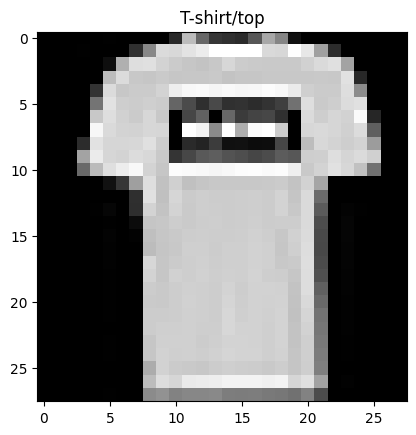

In [22]:
image, label = train_dataset[1]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze(), cmap="gray") # image shape is [1, 28, 28] (colour channels, height, width)
plt.title(classes[label]);

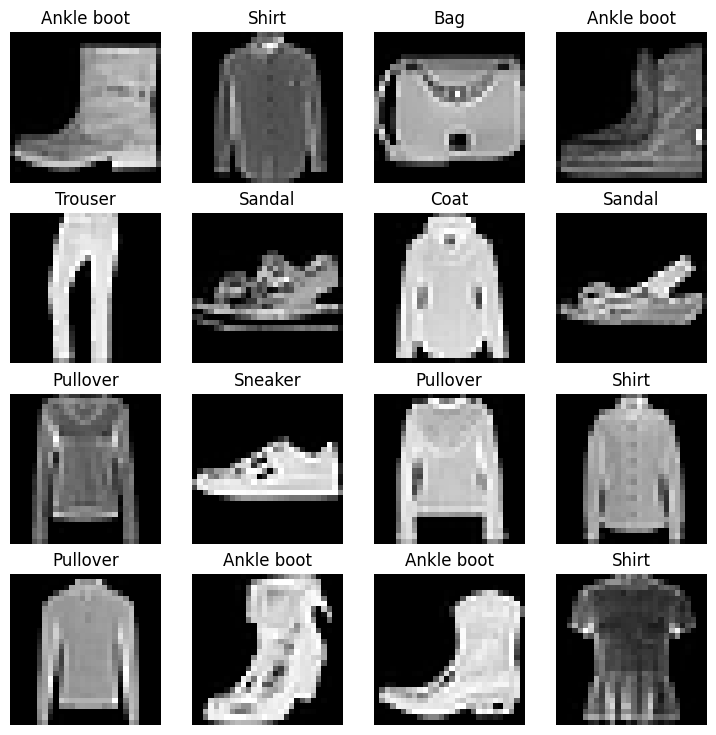

In [23]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_dataset), size=[1]).item()
    img, label = train_dataset[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(classes[label])
    plt.axis(False);

In [24]:
from torch.utils.data import DataLoader
BATCH_SIZE=32   

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [25]:
# next(iter()) prints the first batch

train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

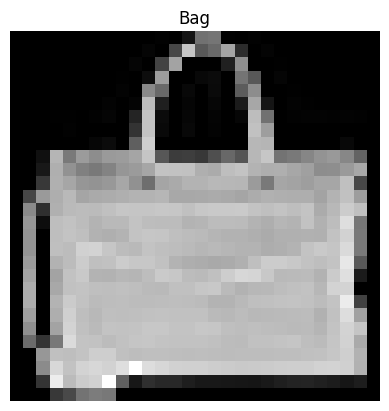

In [26]:

random_id = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_id], train_labels_batch[random_id]

plt.imshow(img.squeeze(), cmap="gray")
plt.title(classes[label])
plt.axis("Off")


In [27]:
class BaseLineModelV0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.linear_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )
        
    def forward(self, x):
        return self.linear_stack(x)

In [28]:
modelV0 = BaseLineModelV0(input_shape=784, hidden_units=10, output_shape=len(classes))
modelV0

BaseLineModelV0(
  (linear_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [29]:
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=modelV0.parameters(), lr=0.1)

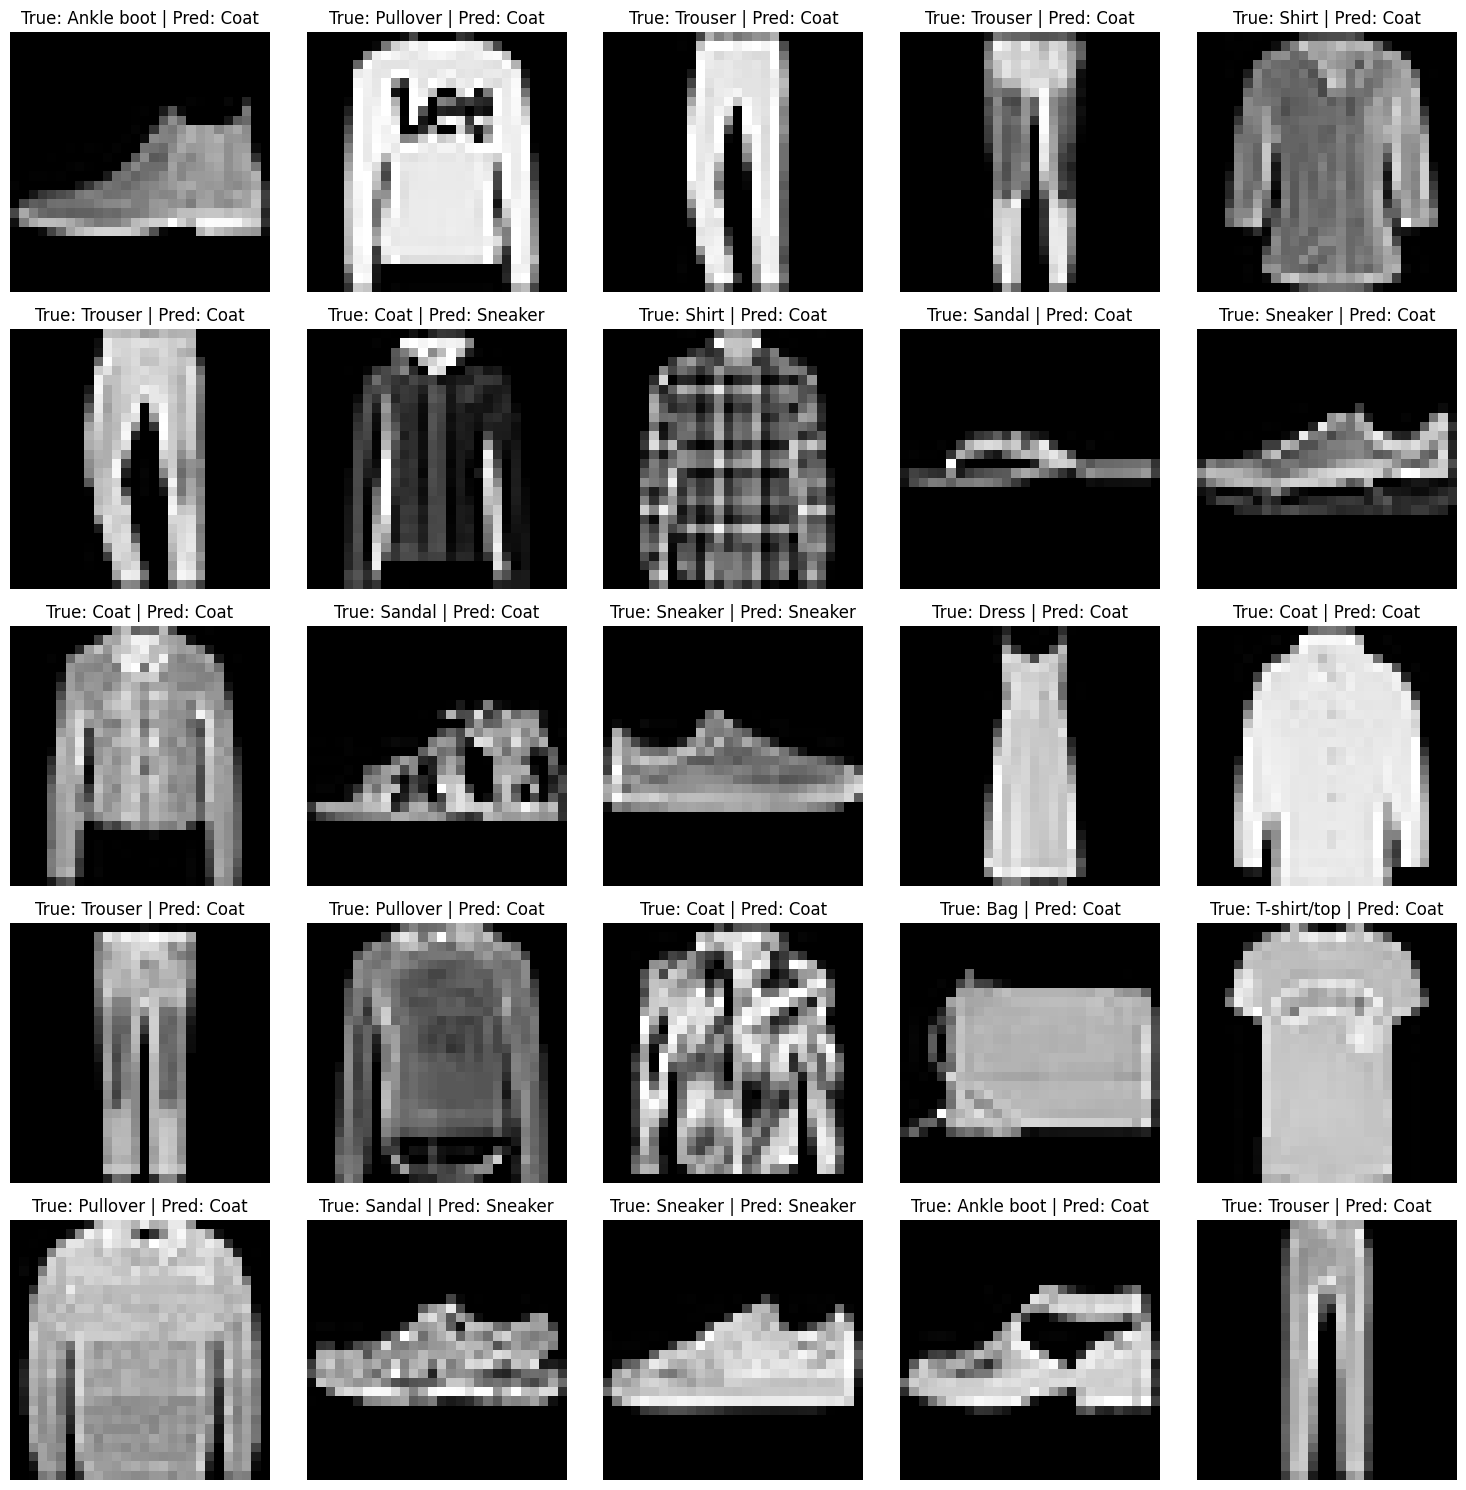

In [30]:
# prediction logits on untrained model
X = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
raw_logits = modelV0(X)
predictions = torch.argmax(raw_logits, dim=1)

plt.figure(figsize=(15, 15))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title(f"True: {classes[test_dataset[i][1]]} | Pred: {classes[predictions[i].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
print(list(modelV0.parameters()))

[Parameter containing:
tensor([[-0.0042, -0.0145,  0.0237,  ..., -0.0319,  0.0206, -0.0111],
        [-0.0272,  0.0052,  0.0173,  ...,  0.0023,  0.0029,  0.0097],
        [ 0.0272, -0.0169,  0.0213,  ...,  0.0307, -0.0014, -0.0287],
        ...,
        [-0.0101, -0.0093,  0.0068,  ..., -0.0126, -0.0139, -0.0208],
        [-0.0275,  0.0082,  0.0330,  ...,  0.0330,  0.0033,  0.0030],
        [-0.0047, -0.0345,  0.0140,  ...,  0.0228,  0.0321, -0.0169]],
       requires_grad=True), Parameter containing:
tensor([ 0.0152, -0.0084,  0.0227, -0.0054, -0.0284, -0.0354, -0.0013,  0.0105,
        -0.0211,  0.0281], requires_grad=True), Parameter containing:
tensor([[ 0.1500,  0.1907,  0.1457, -0.3050, -0.0580,  0.1643,  0.1565, -0.2877,
         -0.1792,  0.2305],
        [-0.2618,  0.2397, -0.0610,  0.0232,  0.1542,  0.0851, -0.2027,  0.1030,
         -0.2715, -0.1596],
        [-0.0555, -0.0633,  0.2302, -0.1726,  0.2654,  0.1473,  0.1029,  0.2252,
         -0.2160, -0.2725],
        [ 0.0118

In [ ]:
# lets train the model

epochs=10

for epoch in range(epochs):
    modelV0.train()

    X = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
    y = torch.tensor([
    train_dataset[i][1]
    for i in range(len(train_dataset))
    ])
    model_logits = modelV0(X)
    model_prob = torch.argmax(torch.softmax(model_logits, dim=1), dim=1)
    loss = loss_fn(model_logits, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    modelV0.eval()   
    
    print(f"Epoch: {epoch + 1}, Loss: {loss:.4f} ") 
    

Epoch: 1, Loss: 2.3319 
Epoch: 2, Loss: 2.2559 


In [ ]:
# prediction logits on trained model
X = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
raw_logits = modelV0(X)
predictions = torch.argmax(raw_logits, dim=1)

plt.figure(figsize=(15, 15))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title(f"True: {classes[test_dataset[i][1]]} | Pred: {classes[predictions[i].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# although our model is performing well on simple linear model lets create a non linear model to see if it get to learn more complex patterns.

In [ ]:
class BaseLineModelV1(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.linear_stack = nn.Sequential(
            nn.Flatten(),
            nn.ReLU(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )
        
    def forward(self, x):
        return self.linear_stack(x)
    
modelV1 = BaseLineModelV1(input_shape=784, hidden_units=10, output_shape=len(classes))
print(modelV1)
print(modelV1.state_dict())

In [ ]:
optimizer = torch.optim.SGD(params=modelV1.parameters(), lr=0.1)

In [ ]:
# lets train the model
epochs=10

for epoch in range(epochs):
    modelV1.train()

    X = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
    y = torch.tensor([
    train_dataset[i][1]
    for i in range(len(train_dataset))
    ])
    model_logits = modelV1(X)
    model_prob = torch.argmax(torch.softmax(model_logits, dim=1), dim=1)
    loss = loss_fn(model_logits, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    modelV1.eval()   
    
    print(f"Epoch: {epoch + 1}, Loss: {loss:.4f} ") 
    

In [ ]:
# prediction logits on trained model
X = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
raw_logits = modelV1(X)
predictions = torch.argmax(raw_logits, dim=1)

plt.figure(figsize=(15, 15))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title(f"True: {classes[test_dataset[i][1]]} | Pred: {classes[predictions[i].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()